## Import Prerequis

In [1]:
import sys
import os
import subprocess
import ctypes
import numpy as np
import matplotlib.pyplot as plt

# Configuration des chemins vers ton projet
sys.path.append(os.path.abspath(os.path.join('..')))

### Compile Library C and generate JSON (make)

In [2]:
try:
    result = subprocess.run(
        "make -C ../libc clean && make -C ../libc",
        shell=True,
        capture_output=True,
        text=True
    )
    # print(result.stdout)

    if result.stderr:
        print(result.stderr)
    
    if result.returncode != 0:
        print(f"Build failed with exit code {result.returncode}")
        sys.exit(1)
    else:
        print("Build succeeded.")

except Exception as e:
    print(f"Build failed: {e}")
    sys.exit(1)

Build succeeded.


## Import Loader

In [3]:
from engine.interop.loader import Loader
from engine.interop.linearModel import LinearModel

# Chargement du Singleton Loader
LIB_NAME = "libc"
LIB_FOLDER = "../libc"
BUILD_FOLDER = "../libc/build"
SPECS_FOLDER = "../libc/specs"
DEPENDENCIES_FOLDER = r"C:\msys64\mingw64\bin"

Loader.loadLibrary(LIB_NAME, lib_folder=LIB_FOLDER, build_folder=BUILD_FOLDER, specs_folder=SPECS_FOLDER, dependencies_bin_folder=DEPENDENCIES_FOLDER)
print("✓ Bibliothèque C chargée avec succès !")

✓ Bibliothèque C chargée avec succès !


# TEST 1 – Classification Linéaire (Rosenblatt)

=== Étape 1 : Génération des données de classification ===
=== Étape 2 : Résolution One-Shot (Pseudo-Inverse) ===
✓ Modèle entraîné instantanément avec OpenBLAS / LAPACK !

=== Étape 3 : Extraction des poids C pour la droite ===
  -> Biais (w0) = -1.8956
  -> Poids w1   = 0.2798
  -> Poids w2   = 0.2012

=== Étape 4 : Test des prédictions (is_classification=True) ===
  -> Point proche du cluster Rouge [1.5, 1.5] | Classe prédite : -1 (Attendu : -1)
  -> Point proche du cluster Bleu [6.5, 6.5]  | Classe prédite : 1 (Attendu : 1)

=== Étape 5 : Affichage graphique avec Matplotlib ===


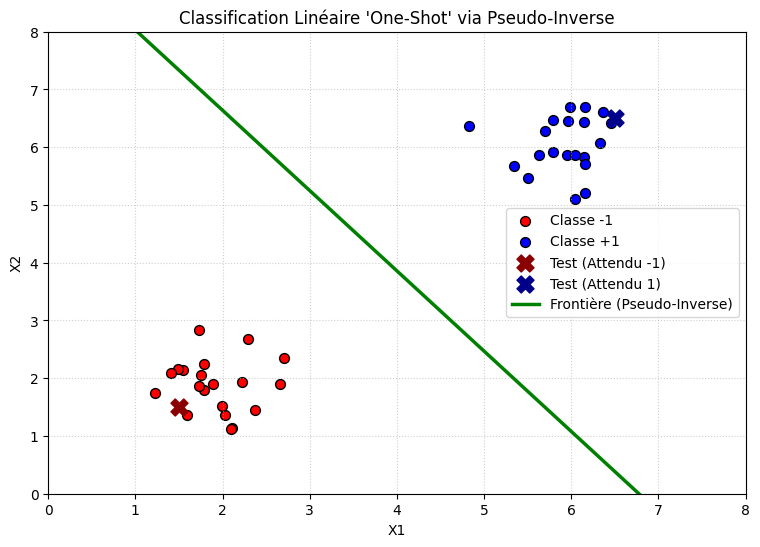

In [4]:
# =========================================================================
# TEST : CLASSIFICATION ONE-SHOT VIA PSEUDO-INVERSE (Moindres Carrés)
# =========================================================================
print("=== Étape 1 : Génération des données de classification ===")
np.random.seed(42)

# On génère 20 points pour la classe -1 (centrés autour de [2, 2])
class_minus_1 = np.random.multivariate_normal([2, 2], [[0.2, 0], [0, 0.2]], 20)
# On génère 20 points pour la classe +1 (centrés autour de [6, 6])
class_plus_1 = np.random.multivariate_normal([6, 6], [[0.2, 0], [0, 0.2]], 20)

# On fusionne le tout pour créer le dataset
X_clf = np.vstack((class_minus_1, class_plus_1))
Y_clf = np.hstack((np.full(20, -1.0), np.full(20, 1.0)))

# Conversion en listes Python standard pour ton wrapper C
dataset_inputs = X_clf.flatten().tolist()
dataset_expected = Y_clf.tolist()

print("=== Étape 2 : Résolution One-Shot (Pseudo-Inverse) ===")
# On utilise EXACTEMENT la même fonction de régression que tu as corrigée !
model_oneshot = LinearModel.init_and_calculate_best_weights_with_pseudo_inverse(
    dataset_inputs, 
    dataset_expected
)
print("✓ Modèle entraîné instantanément avec OpenBLAS / LAPACK !")

print("\n=== Étape 3 : Extraction des poids C pour la droite ===")
# On extrait les poids (Biais, W1, W2) via ctypes pour pouvoir tracer la ligne
weights_ptr = ctypes.cast(model_oneshot.ptr, ctypes.POINTER(ctypes.c_void_p))[0]
trained_weights = ctypes.cast(weights_ptr, ctypes.POINTER(ctypes.c_float * 3)).contents
w0 = trained_weights[0]  # Biais
w1 = trained_weights[1]  # Poids feature 1 (X1)
w2 = trained_weights[2]  # Poids feature 2 (X2)

print(f"  -> Biais (w0) = {w0:.4f}")
print(f"  -> Poids w1   = {w1:.4f}")
print(f"  -> Poids w2   = {w2:.4f}")

print("\n=== Étape 4 : Test des prédictions (is_classification=True) ===")
# On s'assure que predict() utilise bien la fonction de classification de ta lib C
test_rouge = [1.5, 1.5]
test_bleu = [6.5, 6.5]

pred_rouge = model_oneshot.predict(test_rouge, is_classification=True)
pred_bleu = model_oneshot.predict(test_bleu, is_classification=True)

print(f"  -> Point proche du cluster Rouge {test_rouge} | Classe prédite : {pred_rouge} (Attendu : -1)")
print(f"  -> Point proche du cluster Bleu {test_bleu}  | Classe prédite : {pred_bleu} (Attendu : 1)")

print("\n=== Étape 5 : Affichage graphique avec Matplotlib ===")
plt.figure(figsize=(9, 6))

# On trace les points du dataset
plt.scatter(class_minus_1[:, 0], class_minus_1[:, 1], color='red', label='Classe -1', edgecolors='k', s=50)
plt.scatter(class_plus_1[:, 0], class_plus_1[:, 1], color='blue', label='Classe +1', edgecolors='k', s=50)

# On trace les deux points de test pour voir où ils tombent
plt.scatter([test_rouge[0]], [test_rouge[1]], color='darkred', marker='X', s=150, label='Test (Attendu -1)')
plt.scatter([test_bleu[0]], [test_bleu[1]], color='darkblue', marker='X', s=150, label='Test (Attendu 1)')

# Calcul et tracé de la frontière de décision : w0 + w1*x1 + w2*x2 = 0  =>  x2 = -(w1*x1 + w0) / w2
x1_line = np.linspace(0, 8, 100)
if w2 != 0:
    x2_line = -(w1 * x1_line + w0) / w2
    plt.plot(x1_line, x2_line, color='green', linestyle='-', linewidth=2.5, label='Frontière (Pseudo-Inverse)')

plt.title("Classification Linéaire 'One-Shot' via Pseudo-Inverse")
plt.xlabel("X1")
plt.ylabel("X2")
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# TEST 2 – Régression Linéaire (Pseudo-Inverse)

Modèle Régression Appris -> Biais (Théorique 4.0): 4.6519, W1 (Théorique 2.5): 2.3302


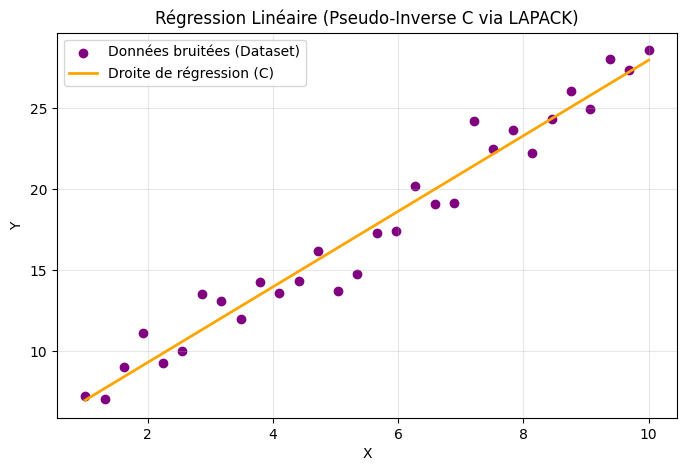

In [ ]:
# 1. Génération des données de régression (1D -> x et y)
np.random.seed(42)
X_reg = np.linspace(1, 10, 30).reshape(-1, 1)
# Équation cible : y = 2.5 * x + 4.0 + un peu de bruit aléatoire
Y_reg = 2.5 * X_reg.flatten() + 4.0 + np.random.normal(0, 1.5, 30)

# 2. Résolution directe via ta lib C (Pseudo-inverse)
# Attention : ta fonction attend des listes de floats natives
model_reg = LinearModel.init_and_calculate_best_weights_with_pseudo_inverse(
    X_reg.flatten().tolist(), 
    Y_reg.tolist()
)

# 3. Extraction des poids (1 feature + 1 biais = 2 poids)
weights_ptr_reg = ctypes.cast(model_reg.ptr, ctypes.POINTER(ctypes.c_void_p))[0]
trained_weights_reg = ctypes.cast(weights_ptr_reg, ctypes.POINTER(ctypes.c_float * 2)).contents
bias_reg, w1_reg = trained_weights_reg[0], trained_weights_reg[1]

print(f"Modèle Régression Appris -> Biais (Théorique 4.0): {bias_reg:.4f}, W1 (Théorique 2.5): {w1_reg:.4f}")

# 4. Affichage Matplotlib
plt.figure(figsize=(8, 5))
plt.scatter(X_reg, Y_reg, color='purple', label='Données bruitées (Dataset)')

# Tracé de la droite de régression prédite par le modèle : y = w1*x + bias
x_domain = np.linspace(1, 10, 100)
y_pred = w1_reg * x_domain + bias_reg
plt.plot(x_domain, y_pred, color='orange', linewidth=2, label='Droite de régression (C)')

plt.title("Régression Linéaire (Pseudo-Inverse C via LAPACK)")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()